<a href="https://colab.research.google.com/github/Gnissan-BIA/Assignments/blob/main/Assignment_14_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import libraries

In [1]:
# \\Install
!pip install fairlearn lime shap imbalanced-learn openml -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    true_positive_rate
)

from imblearn.over_sampling import SMOTE

import shap
import lime
import lime.lime_tabular


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 41.6 MB/s eta 0:00:00


#Load dataset

In [2]:
adult = fetch_openml(name="adult", version=2, as_frame=True)
data = adult.frame.copy()

print("First 5 rows:")
print(data.head())
print("\nDataset shape:", data.shape)


First 5 rows:
   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  cl

#Define features, target and sensitive attribure

In [3]:
target_col = "class"

# Convert target to binary
data[target_col] = data[target_col].apply(lambda x: 1 if x == ">50K" else 0)

X = data.drop(columns=[target_col])
y = data[target_col]

# Sensitive attribute for fairness analysis
sensitive_feature = data["sex"]

print("\nTarget distribution:")
print(y.value_counts())

print("\nSensitive feature distribution:")
print(sensitive_feature.value_counts())



Target distribution:
class
0    37155
1    11687
Name: count, dtype: int64

Sensitive feature distribution:
sex
Male      32650
Female    16192
Name: count, dtype: int64


# Handle missing values

In [4]:
X = X.copy()

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Fill numeric missing values with median
for col in numeric_features:
    X[col] = X[col].fillna(X[col].median())

# Fill categorical missing values with mode
for col in categorical_features:
    X[col] = X[col].fillna(X[col].mode()[0])


# One hot encoding categorical variables

In [5]:

X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print("\nEncoded feature shape:", X.shape)


Encoded feature shape: (48842, 97)


#Train Test Split

In [6]:
X_train, X_test, y_train, y_test, sf_train, sf_test = train_test_split(
    X, y, sensitive_feature,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (39073, 97)
Test shape: (9769, 97)


#Scaling Features

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)


#Handle class imbalance with SMOTE

In [8]:
# Apply SMOTE only on training data

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nClass distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())



Class distribution before SMOTE:
class
0    29724
1     9349
Name: count, dtype: int64

Class distribution after SMOTE:
class
0    29724
1    29724
Name: count, dtype: int64


#Train Logistic Regression Model

In [9]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_resampled, y_train_resampled)


LogisticRegression(max_iter=1000)

#Make Predictions

In [10]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

#Model performance


Accuracy: 0.8070426860477019

Confusion Matrix:
[[5923 1508]
 [ 377 1961]]


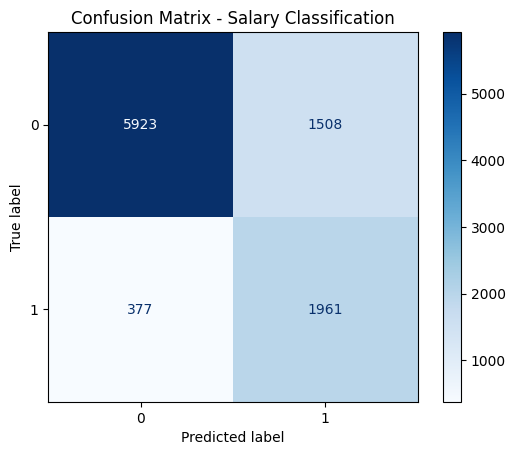


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.80      0.86      7431
           1       0.57      0.84      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769



In [11]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Salary Classification")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


#Fairness Analysis


Overall Fairness Metrics:
selection_rate         0.355103
false_positive_rate    0.202934
true_positive_rate     0.838751
dtype: float64

Fairness Metrics by Group:
        selection_rate  false_positive_rate  true_positive_rate
sex                                                            
Female        0.138386             0.067978            0.703601
Male          0.463594             0.289212            0.863429


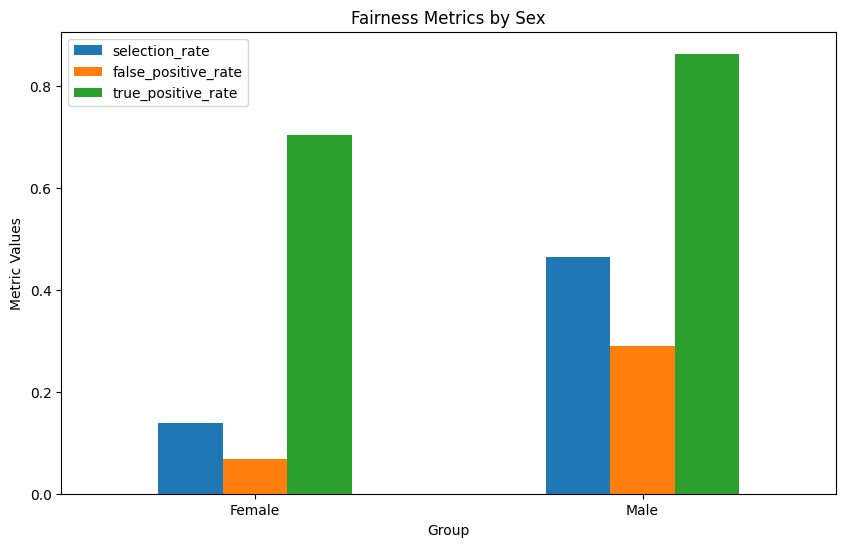

In [12]:
metrics = {
    "selection_rate": selection_rate,
    "false_positive_rate": false_positive_rate,
    "true_positive_rate": true_positive_rate
}

mf = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sf_test
)

print("\nOverall Fairness Metrics:")
print(mf.overall)

print("\nFairness Metrics by Group:")
print(mf.by_group)

mf.by_group.plot(kind="bar", figsize=(10, 6))
plt.title("Fairness Metrics by Sex")
plt.ylabel("Metric Values")
plt.xlabel("Group")
plt.xticks(rotation=0)
plt.show()

#SHAQ explainability


SHAP Summary Plot:


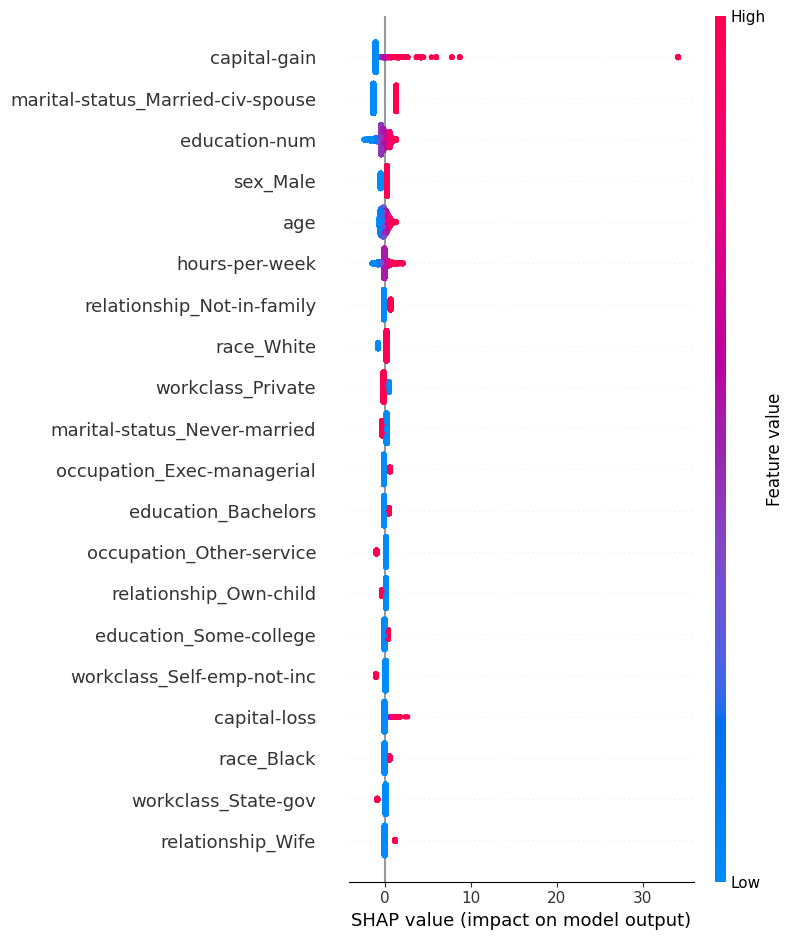


SHAP Waterfall Plot for First Test Sample:


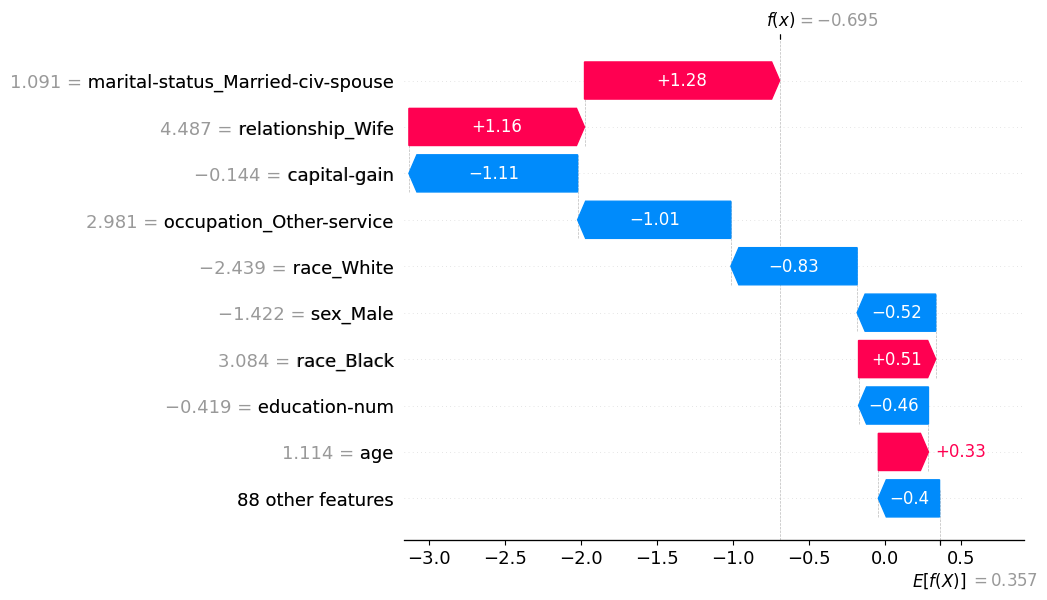

In [13]:
explainer_shap = shap.Explainer(model, X_train_resampled)
shap_values = explainer_shap(X_test_scaled)

print("\nSHAP Summary Plot:")
shap.summary_plot(shap_values, X_test_scaled)

print("\nSHAP Waterfall Plot for First Test Sample:")
shap.plots.waterfall(shap_values[0])


#LIME explainability


LIME Explanation for First Test Sample:
capital-gain <= -0.14: -0.4316
education_Preschool <= -0.04: 0.3780
native-country_Trinadad&Tobago <= -0.02: 0.3249
occupation_Priv-house-serv <= -0.07: 0.3210
native-country_Columbia <= -0.04: 0.2522
marital-status_Married-AF-spouse <= -0.03: -0.2313
native-country_Outlying-US(Guam-USVI-etc) <= -0.02: 0.1672
native-country_Guatemala <= -0.04: 0.1645
native-country_Laos <= -0.02: 0.0863
native-country_Honduras <= -0.02: 0.0619


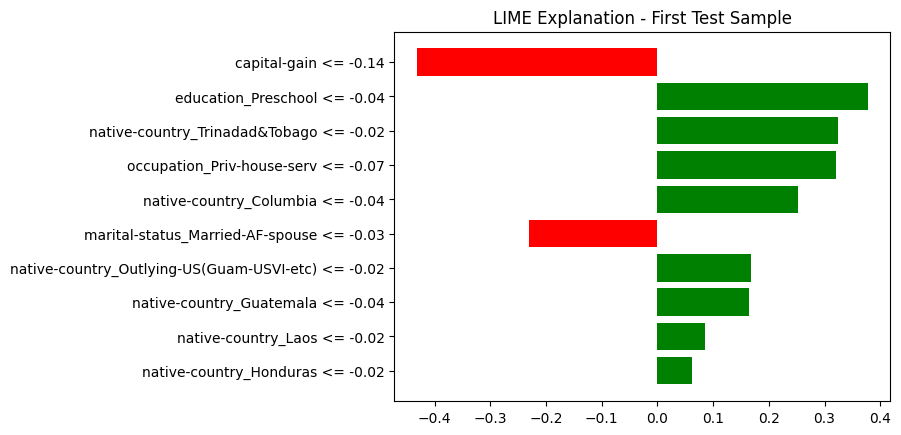

In [14]:

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_resampled),
    feature_names=X.columns.tolist(),
    class_names=["<=50K", ">50K"],
    mode="classification"
)

exp = explainer_lime.explain_instance(
    data_row=X_test_scaled.iloc[0].values,
    predict_fn=model.predict_proba
)

print("\nLIME Explanation for First Test Sample:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

fig = exp.as_pyplot_figure()
plt.title("LIME Explanation - First Test Sample")
plt.show()